# Growth Rate Analysis by Chamber Location

This notebook analyzes growth rates (inverted decay rates) across chamber positions and performs statistical comparisons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.linear_model import LinearRegression
from scipy import stats

In [2]:
# Load data
df = pd.read_csv('1_fluo_binary_metabolic_gradient.csv')

# Prepare data
bin_labels = {0: 'Back', 1: 'Middle', 2: 'Opening'}
df['y_bins'] = pd.cut(df['y'], bins=3, labels=False).astype(int)
df['y_bin_label'] = df['y_bins'].map(bin_labels)
df['time_hours'] = df['frame_number'] * (5 / 60)

In [3]:
# Publication style setup
plt.rcdefaults()
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 8
rcParams['axes.linewidth'] = 0.5
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['xtick.major.size'] = 3
rcParams['ytick.major.size'] = 3
rcParams['pdf.fonttype'] = 42  # TrueType fonts for Illustrator
rcParams['ps.fonttype'] = 42

# Filter to first 1.5 hours
df_decay = df[df['time_hours'] <= 1.5].copy()
df_decay['log_intensity'] = np.log(df_decay['intensity_raw_mcherry'])

In [4]:
# Collect growth rates (negative decay rates)
position_slopes = {'Back': [], 'Middle': [], 'Opening': []}
bins_sorted = ['Back', 'Middle', 'Opening']
palette = sns.color_palette("viridis", n_colors=len(bins_sorted))

unique_chambers = df_decay['pos'].unique()
print(f"Processing {len(unique_chambers)} chambers...")

# Calculate growth rate for each position in each chamber
for chamber_id in unique_chambers:
    chamber_data = df_decay[df_decay['pos'] == chamber_id]
    
    for bin_label in bins_sorted:
        position_data = chamber_data[chamber_data['y_bin_label'] == bin_label]
        
        if len(position_data) > 2:
            X = position_data['time_hours'].values.reshape(-1, 1)
            y = position_data['log_intensity'].values
            
            model = LinearRegression().fit(X, y)
            slope = model.coef_[0]
            
            # Convert decay rate to growth rate (multiply by -1)
            growth_rate = -1 * slope
            position_slopes[bin_label].append(growth_rate)

Processing 7 chambers...



Saved to: S7C_metabolic_gradient.pdf


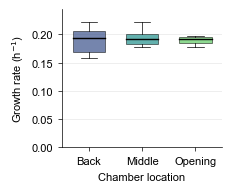

In [6]:
# Create figure (6 cm × 5 cm)
fig, ax = plt.subplots(1, 1, figsize=(6/2.54, 5/2.54))

# Prepare data for boxplot
box_data = [position_slopes[pos] for pos in bins_sorted]

# Create boxplot
bp = ax.boxplot(box_data, positions=range(len(bins_sorted)), labels=bins_sorted,
                patch_artist=True, widths=0.6, showfliers=False,
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(linewidth=0.5),
                capprops=dict(linewidth=0.5),
                boxprops=dict(linewidth=0.5))

# Color boxes
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Styling
ax.set_xlabel('Chamber location')
ax.set_ylabel('Growth rate (h$^{-1}$)')
ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, linestyle='-')
ax.set_axisbelow(True)
ax.set_ylim(bottom=0, top=max(max(slopes) for slopes in box_data) * 1.1)

plt.tight_layout()

# Export to PDF
output_path = 'S7C_metabolic_gradient.pdf'
plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"\nSaved to: {output_path}")

plt.show()


In [6]:
# Print statistics
print("\n" + "="*60)
print("GROWTH RATE STATISTICS (decay rate × -1)")
print("="*60)
print(f"{'Position':<12} {'N':<5} {'Mean±SD':<18} {'Median':<10}")
print("-" * 60)

for pos in bins_sorted:
    slopes = position_slopes[pos]
    if len(slopes) > 0:
        mean_val = np.mean(slopes)
        std_val = np.std(slopes)
        median_val = np.median(slopes)
        print(f"{pos:<12} {len(slopes):<5} {mean_val:.4f} ± {std_val:.4f}    {median_val:.4f}")


GROWTH RATE STATISTICS (decay rate × -1)
Position     N     Mean±SD            Median    
------------------------------------------------------------
Back         7     0.1889 ± 0.0228    0.1928
Middle       7     0.1909 ± 0.0196    0.1912
Opening      7     0.1896 ± 0.0072    0.1914


In [7]:
# Per-chamber statistics
print("\n" + "="*60)
print("PER-CHAMBER STATISTICS")
print("="*60)
print(f"{'Chamber':<12} {'Mean growth rate (h⁻¹)':<24} {'CV between positions (%)':<20}")
print("-"*60)

chamber_means = []
chamber_cvs = []

for i, chamber_id in enumerate(unique_chambers):
    rates = [position_slopes['Back'][i], 
             position_slopes['Middle'][i], 
             position_slopes['Opening'][i]]
    
    mean_rate = np.mean(rates)
    cv = (np.std(rates) / mean_rate) * 100
    
    chamber_means.append(mean_rate)
    chamber_cvs.append(cv)
    
    print(f"{chamber_id:<12} {mean_rate:.4f}                   {cv:.1f}")

print("-"*60)
print(f"{'Average':<12} {np.mean(chamber_means):.4f} ± {np.std(chamber_means):.4f}        {np.mean(chamber_cvs):.1f} ± {np.std(chamber_cvs):.1f}")


PER-CHAMBER STATISTICS
Chamber      Mean growth rate (h⁻¹)   CV between positions (%)
------------------------------------------------------------
pos18        0.2140                   5.4
pos19        0.1948                   6.8
pos20        0.1973                   2.1
pos21        0.1966                   1.8
pos23        0.1806                   9.2
pos24        0.1799                   3.7
pos25        0.1655                   5.6
------------------------------------------------------------
Average      0.1898 ± 0.0146        5.0 ± 2.4


In [8]:
# Statistical comparisons
print("\n" + "="*60)
print("STATISTICAL COMPARISONS (t-tests)")
print("="*60)

positions = list(position_slopes.keys())
for i in range(len(positions)):
    for j in range(i+1, len(positions)):
        pos1, pos2 = positions[i], positions[j]
        slopes1, slopes2 = position_slopes[pos1], position_slopes[pos2]

        if len(slopes1) > 1 and len(slopes2) > 1:
            statistic, p_value = stats.ttest_ind(slopes1, slopes2)
            print(f"{pos1} vs {pos2}: t={statistic:.3f}, p={p_value:.4f}")

# One-way ANOVA for overall comparison
if all(len(slopes) > 1 for slopes in position_slopes.values()):
    f_stat, p_anova = stats.f_oneway(*position_slopes.values())
    print(f"\nOne-way ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")


STATISTICAL COMPARISONS (t-tests)
Back vs Middle: t=-0.163, p=0.8729
Back vs Opening: t=-0.065, p=0.9494
Middle vs Opening: t=0.161, p=0.8745

One-way ANOVA: F=0.020, p=0.9804
